In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"parralex","key":"0c383bd852eb531b27efea09f239a555"}'}

In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:12<00:00, 205MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile('chest-xray-pneumonia.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [ ]:
train_dir = 'data/chest_xray/train'
val_dir = 'data/chest_xray/val'
test_dir = 'data/chest_xray/test'
batch_size = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='binary'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='binary'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Layers Freeze**

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30
)

Epoch 1/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.8016 - loss: 0.4129 - val_accuracy: 0.8125 - val_loss: 0.4190
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.8806 - loss: 0.2659 - val_accuracy: 0.8750 - val_loss: 0.3394
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.9107 - loss: 0.2214 - val_accuracy: 0.8750 - val_loss: 0.3276
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.9132 - loss: 0.2063 - val_accuracy: 0.8750 - val_loss: 0.3236
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9287 - loss: 0.1805 - val_accuracy: 0.8125 - val_loss: 0.3224
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.9262 - loss: 0.1832 - val_accuracy: 0.8125 - val_loss: 0.3425
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9273 - loss: 0.1735 - val_accuracy: 0.8125 - val_loss: 0.3564
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.9308 - loss: 0.1641 - val_accuracy: 0.8125 - v

In [ ]:
for layer in base_model.layers[-60:]:
    layer.trainable = True

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
)

Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.8668 - loss: 0.3638 - val_accuracy: 0.6250 - val_loss: 1.1808
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.9091 - loss: 0.2564 - val_accuracy: 0.5625 - val_loss: 1.7938
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.9225 - loss: 0.2127 - val_accuracy: 0.5625 - val_loss: 2.0152
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9354 - loss: 0.1743 - val_accuracy: 0.5625 - val_loss: 2.3767
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.9383 - loss: 0.1661 - val_accuracy: 0.5625 - val_loss: 2.4774
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9457 - loss: 0.1505 - val_accuracy: 0.6250 - val_loss: 2.5148
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9473 - loss: 0.1411 - val_accuracy: 0.5000 - val_loss: 2.8803
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.9571 - loss: 0.1176 - val_accuracy: 0.5000 - v

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 506ms/step - accuracy: 0.8045 - loss: 0.9807
Test Accuracy: 0.8044871687889099


In [ ]:
train_acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

plt.figure(figsize=(8,5))
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')

plt.title(' Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

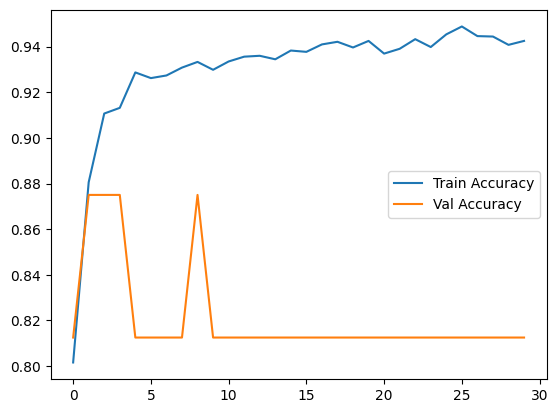

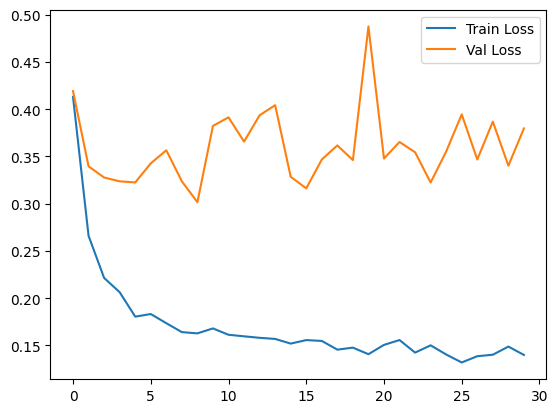

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.legend()
plt.show()

plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 459ms/step - accuracy: 0.8045 - loss: 0.9807
Test Accuracy: 0.8044871687889099


10/10 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step


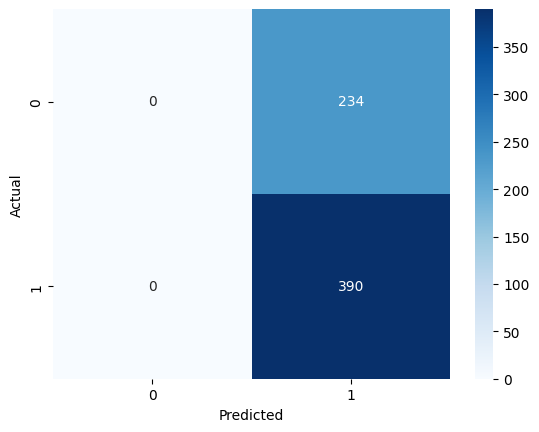

In [ ]:
predictions = model.predict(test_data)
predicted_classes = (predictions > 0.5).astype("int32")

true_classes = test_data.classes

cm = confusion_matrix(true_classes, predicted_classes)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
print(classification_report(true_classes, predicted_classes, target_names=['Normal', 'Pneumonia']))

              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00       234
   Pneumonia       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.7007 - loss: 0.6208 - val_accuracy: 0.5000 - val_loss: 0.8447
Epoch 2/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.7408 - loss: 0.5830 - val_accuracy: 0.5000 - val_loss: 0.8573
Epoch 3/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.7406 - loss: 0.5805 - val_accuracy: 0.5000 - val_loss: 0.8540
Epoch 4/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.7419 - loss: 0.5795 - val_accuracy: 0.5000 - val_loss: 0.8464
Epoch 5/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.7427 - loss: 0.5750 - val_accuracy: 0.5000 - val_loss: 0.8110
Epoch 6/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.7429 - loss: 0.5769 - val_accuracy: 0.5000 - val_loss: 0.7797
Epoch 7/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.7419 - loss: 0.5718 - val_accuracy: 0.5000 - val_loss: 0.7709
Epoch 8/10
82/82 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.7429 - loss: 0.5739 - val_accuracy: 0.5000 - v

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Final Test Accuracy:", test_acc)
print("Final Test Loss:", test_loss)

10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 774ms/step - accuracy: 0.6250 - loss: 0.6711
Final Test Accuracy: 0.625
Final Test Loss: 0.6711127161979675
